# L22: Neural Network - Galaxies vs quasars

For the last coding assignment, you'll need to implement a neural network. We'll look at a relatively simple binary classification problem.

**Tasks**
1. Remember: scale your data appropriately
2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)
3. Decide your optimization metric.
4. Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)
5. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit learn. This is an opportunity to pick the one you're most interested in learning.
6. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best. Do your best now to optimize the network architecture. Be creative!
7. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.

**A few tips**
- In scikit-learn, remember that you can utilize all availables cores on your machine with n_jobs=-1. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use GridSearchCV already. For Tensorflow, there's a really cool tool called Tensorboard

**Dataset**
Go back to our SDSS data we’ve used in Lecture 19: '/galaxyquasar.csv'. We had color differences, and the task was to classifty quasars vs
galaxies. Repeat that task with a neural network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [2]:
path = "/Users/francescarattegni/reps/astrostatistics_bicocca_2025/solutions"
data = pd.read_csv(path+'/galaxyquasar.csv')
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
data['target'] = data['class'].map({'GALAXY': 0, 'QSO': 1})

In [4]:
# Color array
data['u-g'] = data['u'] - data['g']
data['g-r'] = data['g'] - data['r']
data['r-i'] = data['r'] - data['i']
data['i-z'] = data['i'] - data['z']

colors = ['u-g', 'g-r', 'r-i', 'i-z']

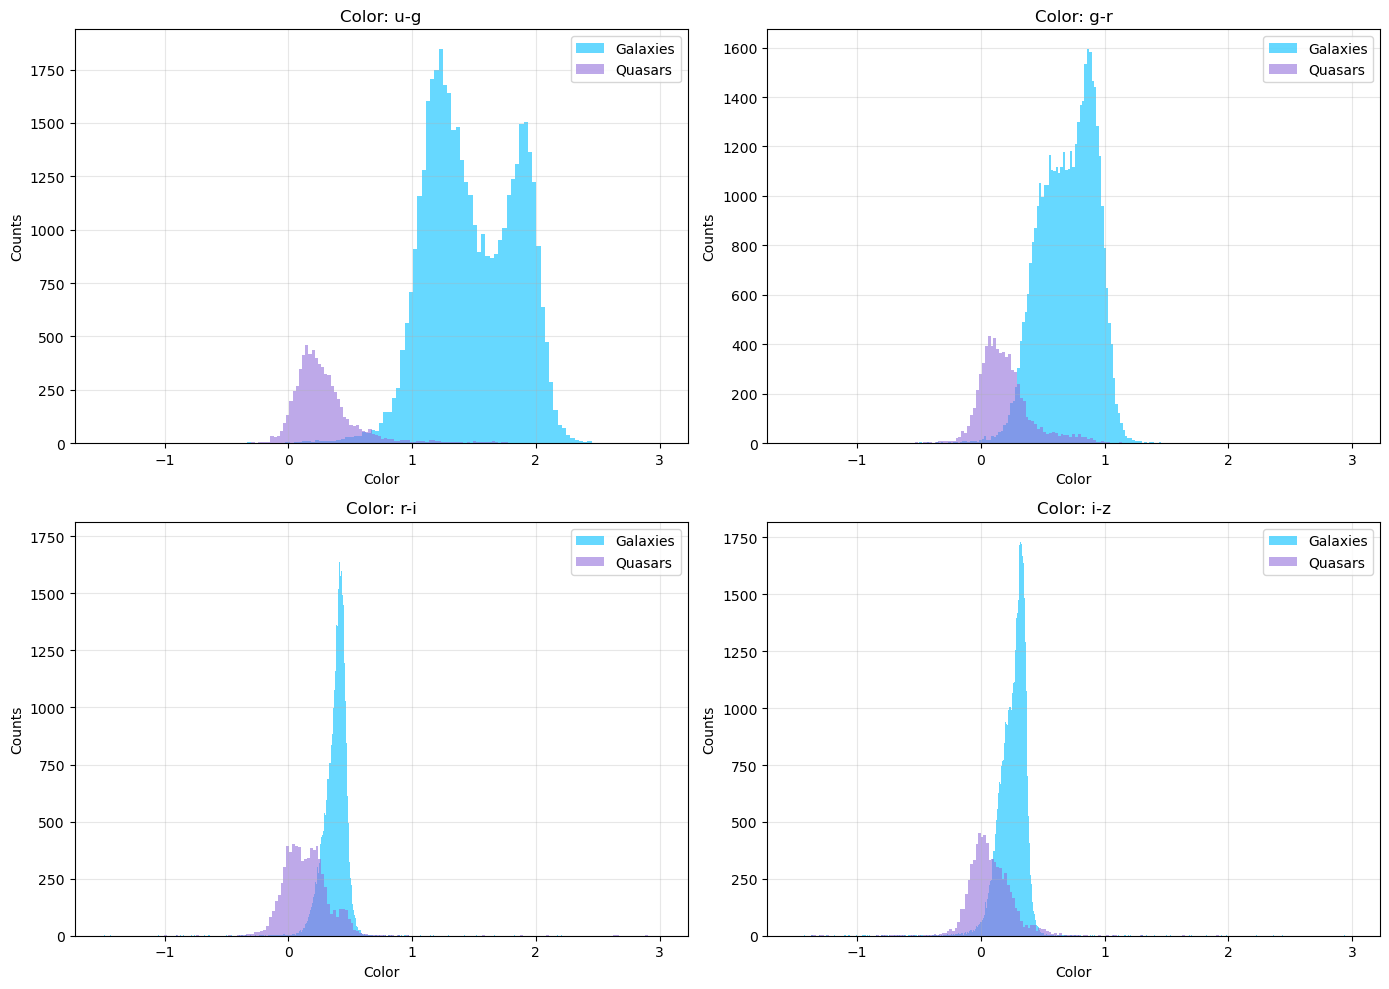

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, color in enumerate(colors):
    galaxies = data[data['target'] == 0][color]
    qso = data[data['target'] == 1][color]

    axes[i].hist(galaxies, bins='fd', range=(-1.5, 3), alpha=0.6, color='deepskyblue', label='Galaxies')
    axes[i].hist(qso, bins='fd', range=(-1.5, 3), alpha=0.6, color='mediumpurple', label='Quasars')

    axes[i].set_title(f'Color: {color}', fontsize=12)
    axes[i].set_xlabel('Color')
    axes[i].set_ylabel('Counts')
    axes[i].legend()
    axes[i].grid(alpha=0.3) 

plt.tight_layout()
plt.show()


In [6]:
# let's divide the data in training and test set
X=data[colors]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (40000, 4)
Test set: (10000, 4)


In [7]:
# let's scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers
from keras_tuner import HyperModel
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters

* **Input**: 4 neuroni ---> 4 colori definiti per ogni galassia/quasar
* **Hidden Layers** ---> Da decidere ---> possiamo iniziare con un solo layer e poi trovare il numero ottimale usando la CV
* **Output**: 1 neurone ---> l'output sarà una probabilità (numero tra 0 e 1)

* Anche il numero di nuroni per ogni layer è da specificare (trovare il valore ottimale)
* **Activation Function** --->  ReLU, Sigmoid

In [10]:
# let's define the model
model = keras.Sequential([layers.Dense(32, activation='relu', input_shape=(4,)), layers.Dense(1, activation='sigmoid')])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Training
history = model.fit(X_train_scaled, y_train,
    epochs=20,
    batch_size=64,          
    validation_split=0.2,   
    verbose=1               
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.9497 - auc: 0.9620 - loss: 0.2616 - val_accuracy: 0.9812 - val_auc: 0.9785 - val_loss: 0.1009
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.9828 - auc: 0.9805 - loss: 0.0812 - val_accuracy: 0.9829 - val_auc: 0.9809 - val_loss: 0.0747
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 589us/step - accuracy: 0.9830 - auc: 0.9820 - loss: 0.0716 - val_accuracy: 0.9829 - val_auc: 0.9832 - val_loss: 0.0727
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - accuracy: 0.9835 - auc: 0.9828 - loss: 0.0698 - val_accuracy: 0.9825 - val_auc: 0.9854 - val_loss: 0.0705
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.9832 - auc: 0.9849 - loss: 0.0684 - val_accuracy: 0.9831 - val_auc: 0.9855 - val_loss: 0.0699
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - accuracy: 0.9835 - auc: 0.9855 - loss: 0.0668 - val_accuracy: 0.9836 - val_auc: 0.9862 - val_loss: 0.0697
Epoch 7/20
500/500 ━━━━━━━━━

Well... now let's look for the best model

In [12]:
# we want to find the best model. hp = hyperparameters 

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],))) # ou input data
    
    # number of layers
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        # dropout rate
        model.add(layers.Dropout(rate=hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))
    
    # output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    # learning rate
    lr = hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')
    optimizer = keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])

    return model


In [13]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_auc", direction="max"), # maximize validation AUC
    max_trials=15,                                      # 15 trials
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='galaxy_quasar_tuning',
    overwrite=True                                      
)

In [14]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', 
    patience=5, 
    mode='max', 
    restore_best_weights=True
)

In [15]:
tuner.search(
    X_train_scaled, y_train, 
    epochs=30, 
    validation_split=0.2, 
    callbacks=[early_stop], 
    batch_size=64              
)

Trial 15 Complete [00h 00m 10s]
val_auc: 0.9932684898376465

Best val_auc So Far: 0.9942297339439392
Total elapsed time: 00h 02m 31s


In [18]:
# 1. Recuperiamo i migliori iperparametri trovati
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("=== BEST HYPERPARAMETERS ===")
print(f"Hidden Layers: {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f" Layers {i}: {best_hps.get(f'units_{i}')} neurons, Dropout rate: {best_hps.get(f'dropout_{i}'):.1f}")
print(f"Optimizer Learning Rate : {best_hps.get('learning_rate'):.5f}")

# 2. Costruiamo automaticamente il modello usando questi parametri vincenti
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

=== BEST HYPERPARAMETERS ===
Hidden Layers: 4
 Layers 0: 224 neurons, Dropout rate: 0.1
 Layers 1: 160 neurons, Dropout rate: 0.1
 Layers 2: 32 neurons, Dropout rate: 0.0
 Layers 3: 32 neurons, Dropout rate: 0.0
Optimizer Learning Rate : 0.00797


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 224)            │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 160)            │        36,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,361 (169.38 KB)

 Trainable params: 43,361 (169.38 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9791 - auc: 0.9837 - loss: 0.0822 - val_accuracy: 0.9816 - val_auc: 0.9845 - val_loss: 0.0770
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9834 - auc: 0.9885 - loss: 0.0608 - val_accuracy: 0.9852 - val_auc: 0.9873 - val_loss: 0.0611
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9841 - auc: 0.9898 - loss: 0.0594 - val_accuracy: 0.9841 - val_auc: 0.9926 - val_loss: 0.0579
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9844 - auc: 0.9900 - loss: 0.0562 - val_accuracy: 0.9834 - val_auc: 0.9903 - val_loss: 0.0585
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9843 - auc: 0.9909 - loss: 0.0545 - val_accuracy: 0.9834 - val_auc: 0.9928 - val_loss: 0.0592


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step
              precision    recall  f1-score   support

      GALAXY       0.98      1.00      0.99      8572
         QSO       0.97      0.90      0.93      1428

    accuracy                           0.98     10000
   macro avg       0.98      0.95      0.96     10000
weighted avg       0.98      0.98      0.98     10000



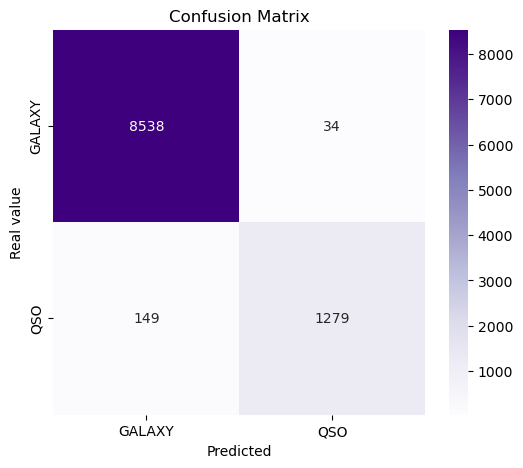

In [22]:
# Test
y_pred_prob = best_model.predict(X_test_scaled)

# conversion probability into binary classes
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

#Classification Report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=['GALAXY', 'QSO']))

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['GALAXY', 'QSO'], yticklabels=['GALAXY', 'QSO'])
plt.xlabel('Predicted')
plt.ylabel('Real value')
plt.title('Confusion Matrix')
plt.show()